In [13]:
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import matplotlib.pyplot as plt
import seaborn as sns
# this contains a dictonary of columns to rename and a metadata dictionary to organize the data into categories

%matplotlib inline

In [14]:
# list of the measures that will be dropped from analyses
measures_to_drop = []
# list of measures to drop NaN values from
remove_nan = []
# list of the different visit types
visit_type = ['bl', 'm03', 'm06', 'm12', 'm18', 'm24', 'm30', 'm36', 'm42', 'm48', 'm54',
              'm60', 'm66', 'm72', 'm78', 'm84', 'm90', 'm96', 'm102', 'm108', 'm114', 'm120']
# dictionary to store visit types with all missing values
no_data_dict = {}

In [32]:
"""dictionary to contain the columns of interest for the models.
These have been broken down into different data types.
"""

columns_to_rename = {### these data are volumetric estimates from the UCSF
                     ### longitudinal dataset
                     # Left hippocampus
                     'ST29SV_UCSFFSL_02_01_16_UCSFFSL51ALL_08_01_16' : 'l_hippocampus_l',
                     # right hippocampus
                     'ST88SV_UCSFFSL_02_01_16_UCSFFSL51ALL_08_01_16' : 'l_hippocampus_r',
                     # Intracranial volume ICV
                     'ST10CV_UCSFFSL_02_01_16_UCSFFSL51ALL_08_01_16' : 'l_icv',
                     # Left entorhinal cortex volume
                     'ST24CV_UCSFFSL_02_01_16_UCSFFSL51ALL_08_01_16' : 'l_entorhinal_l',
                     # Left entorhinal cortex thickness
                     'ST24TA_UCSFFSL_02_01_16_UCSFFSL51ALL_08_01_16' : 'l_entorhinal_l_thick',
                     # Right entorhinal cortex volume
                     'ST83CV_UCSFFSL_02_01_16_UCSFFSL51ALL_08_01_16' : 'l_entorhinal_r',
                     # Right entorhinal cortex thickness
                     'ST83TA_UCSFFSL_02_01_16_UCSFFSL51ALL_08_01_16' : 'l_entorhinal_r_thick',
                     # Third ventricle
                     'ST127SV_UCSFFSL_02_01_16_UCSFFSL51ALL_08_01_16' : 'l_third_ventricle',
                     # Left inferior lateral ventricle
                     'ST30SV_UCSFFSL_02_01_16_UCSFFSL51ALL_08_01_16' : 'l_il_ventricle_l',
                     # Left lateral ventricle
                     'ST37SV_UCSFFSL_02_01_16_UCSFFSL51ALL_08_01_16' : 'l_l_ventricle_l',
                     # Right inferior lateral ventricle
                     'ST89SV_UCSFFSL_02_01_16_UCSFFSL51ALL_08_01_16' : 'l_il_ventricle_r',
                     # Fifth ventricle
                     'ST8SV_UCSFFSL_02_01_16_UCSFFSL51ALL_08_01_16' : 'l_fifth_ventricle',
                     # Right lateral ventricle
                     'ST96SV_UCSFFSL_02_01_16_UCSFFSL51ALL_08_01_16' : 'l_l_ventricle_r',
                     # fourth ventricle
                     'ST9SV_UCSFFSL_02_01_16_UCSFFSL51ALL_08_01_16' : 'l_fourth_ventricle',
                     ### These are from the cross sectional UCSF dataset
                     # Left hippocampus
                     'ST29SV_UCSFFSX_11_02_15_UCSFFSX51_08_01_16' : 'x_hippocampus_l',
                     # Right hippocampus
                     'ST88SV_UCSFFSX_11_02_15_UCSFFSX51_08_01_16' : 'x_hippocampus_r',
                     # Left entorhinal cortex volume
                     'ST24CV_UCSFFSX_11_02_15_UCSFFSX51_08_01_16' : 'x_entorhinal_l',
                     # Left entorhinal cortex thickness
                     'ST24TA_UCSFFSX_11_02_15_UCSFFSX51_08_01_16' : 'x_entorhinal_l_thick',
                     # Right entorhinal cortex volume
                     'ST83CV_UCSFFSX_11_02_15_UCSFFSX51_08_01_16' : 'x_entorhinal_r',
                     # Right entorhinal cortex thickness
                     'ST83TA_UCSFFSX_11_02_15_UCSFFSX51_08_01_16' : 'x_entorhinal_r_thick',
                     ### These are from PET
                     # Hippocampus FDG measure
                     'FNEHC2_BAIPETNMRC_09_12_16' : 'fdg_hippocampus',
                     # Left hippocampus AV45
                     'LEFT_HIPPOCAMPUS_UCBERKELEYAV45_10_17_16' : 'av45_hippocampus_l',
                     # Right hippocampus AV45
                     'RIGHT_HIPPOCAMPUS_UCBERKELEYAV45_10_17_16' : 'av45_hippocampus_r',
                     # Left entorhinal cortex AV45
                     'CTX_LH_ENTORHINAL_UCBERKELEYAV45_10_17_16' : 'av45_entorhinal_l',
                     # Right entorhinal cortex AV45
                     'CTX_RH_ENTORHINAL_UCBERKELEYAV45_10_17_16' : 'av45_entorhinal_r',
                     # Left hippocampus AV1451
                     'LEFT_HIPPOCAMPUS_UCBERKELEYAV1451_10_17_16' : 'av1451_hippocampus_l',
                     # Right hippocampus AV1451
                     'RIGHT_HIPPOCAMPUS_UCBERKELEYAV1451_10_17_16' : 'av1451_hippocampus_r',
                     # Left entorhinal cortex AV1451
                     'CTX_LH_ENTORHINAL_UCBERKELEYAV1451_10_17_16' : 'av1451_entorhinal_l',
                     # Right entorhinal cortex AV1451
                     'CTX_RH_ENTORHINAL_UCBERKELEYAV1451_10_17_16' : 'av1451_entorhinal_r',
                     ### These are from DTI
                     # Left hippocampus fractional anisotropy
                     'FA_CGH_L_DTIROI_04_30_14' : 'fa_hippocampus_l',
                     # Right hippocampus fractional anisotropy
                     'FA_CGH_R_DTIROI_04_30_14' : 'fa_hippocampus_r',
                     # Left hippocampus mean diffusivity
                     'MD_CGH_L_DTIROI_04_30_14' : 'md_hippocampus_l',
                     # Right hippocampus mean diffusivity
                     'MD_CGH_R_DTIROI_04_30_14' : 'md_hippocampus_r'
}

metadata = {'demographic':
                          # Participant roster ID
                          ['RID',
                          # Visit code where bl is baseline
                          'VISCODE',
                          # Dataset that the record belongs to
                          'D1',
                          'D2',
                          # Baseline diagnosis
                          'DX_bl',
                          # Diagnosis change coded as
                          # 1=Stable:NL to NL, 2=Stable:MCI to MCI, 3=Stable:AD to AD,
                          # 4=Conv:NL to MCI, 5=Conv:MCI to AD, 6=Conv:NL to AD,
                          # 7=Rev:MCI to NL, 8=Rev:AD to MCI, 9=Rev:AD to NL,
                          # -1=Not available
                          'DXCHANGE',
                          # Age at baseline
                          'AGE',
                          # Gender
                          'PTGENDER',
                          # Education
                          'PTEDUCAT',
                          # Ethnicity
                          'PTETHCAT',
                          # Marital status at baseline
                          'PTMARRY'],
            'cognitive_tests':
                          # Clinical Dementia Rating Scale Sum of Boxes Scores
                          ### NOTE that bl denotes baseline assessment and != bl
                          ### denotes visit measurement
                          ['CDRSB_bl',
                          'CDRSB',
                          # Alzheimer's Disease Assessment Scale 13
                          'ADAS13_bl',
                          'ADAS13',
                          # Mini mental state examination
                          'MMSE_bl',
                          'MMSE',
                          # Montreal cognitive assessment
                          'MOCA_bl',
                          'MOCA'],
            'ECog':
                          # Ecog measurement memory
                          ['EcogPtMem_bl',
                          'EcogPtMem',
                          # Ecog measurement visual spatial
                          'EcogPtVisspat_bl',
                          'EcogPtVisspat'],
            'MRI':
                          # Hippocampus longitudinal
                          ['l_hippocampus_l',
                          'l_hippocampus_r',
                          # Hippocampus cross sectional
                          'x_hippocampus_l',
                          'x_hippocampus_r',
                          # Entorhinal cortex volume longitudinal
                          'l_entorhinal_l',
                          'l_entorhinal_r',
                          # Entorhinal cortex thickness longitudinal
                          'l_entorhinal_l_thick',
                          'l_entorhinal_r_thick',
                          # Entorhinal cortex volume cross sectional
                          'x_entorhinal_l',
                          'x_entorhinal_r',
                          # Entorhinal cortex thickness longitudinal
                          'x_entorhinal_l_thick',
                          'x_entorhinal_r_thick'],

            'PET':
                          # Average FDG from angular, temporal, and posterior cingulate
                          ['FDG',
                          # FDG baseline
                          'FDG_bl',
                          # Hippocampus FDG
                          'fdg_hippocampus',
                          # Average PIB from frontal cortex, anterior cingulate, precuneus cortex, and parietal cortex
                          'PIB',
                          # Baseline PIB
                          'PIB_bl',
                          # Average AV45 from frontal, anterior cingulate, precuneus, and parietal cortex relative to the cer
                          'AV45',
                          'AV45_bl',
                          # Left hippocampus AV45
                          'av45_hippocampus_l',
                          # Right hippocampus AV45
                          'av45_hippocampus_r',
                          # Left entorhinal cortex AV45
                          'av45_entorhinal_l',
                          # Right entorhinal cortex AV45
                          'av45_entorhinal_r',
                          # Left hippocampus AV1451
                          'av1451_hippocampus_l',
                          # Right hippocampus AV1451
                          'av1451_hippocampus_r',
                          # Left entorhinal cortex AV1451
                          'av1451_entorhinal_l',
                          # Right entorhinal cortex AV1451
                          'av1451_entorhinal_r'],
            'DTI':
                         # Left hippocampus fractional anisotropy
                         ['fa_hippocampus_l',
                         # Right hippocampus fractional anisotropy
                         'fa_hippocampus_r',
                         # Left hippocampus mean diffusivity
                         'md_hippocampus_l',
                         # Right hippocampus mean diffusivity
                         'md_hippocampus_r'],
            'Genetic':
                         # APOE E4
                         ['APOE4']
                          }

dx_change_ids = {1 : 'Stable:NL to NL',
                 2 : 'Stable:MCI to MCI',
                 3 : 'Stable:AD to AD',
                 4 : 'Conv:NL to MCI',
                 5 : 'Conv:MCI to AD',
                 6 : 'Conv:NL to AD',
                 7 : 'Rev:MCI to NL',
                 8 : 'Rev:AD to MCI',
                 9 : 'Rev:AD to NL', 
                 -1 : 'Not available'
                 }

In [36]:
# method to display unique values for each data category
def unique_values(key):
    """
    This method returns an output of all the unique values for a column in a dataframe and will be used
    to identify how missing data is coded for each measurement type."""
    # loop through categories
    for data in metadata[key]:
        # display unique values for each data category
        print(f"Data category {data}:\ntest {df[data].unique()}")

# method to return table of NaN counts
def nan_count(measurement_type, single_measure=False):
    """
    This method returns a dataframe that identifies the number of NaN entries for measurements at different
    visit types and the percentage of NaNs for each visit type. If all entries are NaN, they are omitted 
    from the dataframe and identified as having no measurements for that visit. It also includes a parameter
    for single value measures rather than taking a list of different measurement types.
    """
    # list of single measure or measures for measurement type
    if single_measure:
        measure_list = [measurement_type]
    else:
        measure_list = list(metadata[measurement_type])
    # initiate dataframe
    df_nan = pd.DataFrame(columns=measure_list)
    # list of visit periods where data was not collected
    no_data_visit = []
    # loop through visit types
    for visit in visit_type:
        # extract data for each visit type
        dataframe = df[df.VISCODE == visit]
        # loop through different measures
        for measure in measure_list:
            # fill in
            # sum NaN values per measure
            nan_count = dataframe[measure].isnull().sum()
            df_nan.loc[f'{visit}_NaN_count', measure] = nan_count
            # calculate percentage of NaN in column rounded to one decimal
            df_nan.loc[f'{visit}_percent_of_col', measure] = np.round(nan_count/len(dataframe[measure])*100,1)
        ### this moves visits with all missing data out of the dataframe
        # non baseline measurements
        non_baseline_df = df_nan.filter(items=[measure for measure in measure_list if 'bl' not in measure])
        # check to see if all measurements are NaN for visit
        if non_baseline_df.loc[f'{visit}_percent_of_col',:].sum() == 100*len(non_baseline_df.columns):
            # if all missing, move visit to no data list
            df_nan = df_nan.drop([f'{visit}_NaN_count', f'{visit}_percent_of_col'])
            no_data_visit.append(visit)
    # add visits with no data measurements to no data dict
    no_data_dict[measurement_type] = no_data_visit
    # print out the visits with no data measurements
    print(f'The visits that have no recorded data are {no_data_visit}.')
    # return the dataframe with NaN counts
    return df_nan

In [37]:
# Read in main data to a dataframe. This contains all but the fMRI dataset.
data = pd.read_csv('TADPOLE_D1_D2.csv', dtype=object)
# print shape of dataframe
print(data.shape)

(12741, 1907)


In [38]:
data = data[data['ORIGPROT'] == 'ADNI1']

In [46]:
data.shape

(6940, 1907)

In [47]:
# rename columns
data.rename(columns=columns_to_rename, inplace=True)

In [48]:
# store all columns of interest
col_all = []
for k,v in metadata.items():
    # skip fMRI data as it needs to be merged from a separate file
    if k != 'fMRI':
        for item in v:
            col_all.append(item)

In [49]:
# extract demographic information
df = data[col_all].copy()
# display column names of new dataframe
print(df.columns)

Index(['RID', 'VISCODE', 'D1', 'D2', 'DX_bl', 'DXCHANGE', 'AGE', 'PTGENDER',
       'PTEDUCAT', 'PTETHCAT', 'PTMARRY', 'CDRSB_bl', 'CDRSB', 'ADAS13_bl',
       'ADAS13', 'MMSE_bl', 'MMSE', 'MOCA_bl', 'MOCA', 'EcogPtMem_bl',
       'EcogPtMem', 'EcogPtVisspat_bl', 'EcogPtVisspat', 'l_hippocampus_l',
       'l_hippocampus_r', 'x_hippocampus_l', 'x_hippocampus_r',
       'l_entorhinal_l', 'l_entorhinal_r', 'l_entorhinal_l_thick',
       'l_entorhinal_r_thick', 'x_entorhinal_l', 'x_entorhinal_r',
       'x_entorhinal_l_thick', 'x_entorhinal_r_thick', 'FDG', 'FDG_bl',
       'fdg_hippocampus', 'PIB', 'PIB_bl', 'AV45', 'AV45_bl',
       'av45_hippocampus_l', 'av45_hippocampus_r', 'av45_entorhinal_l',
       'av45_entorhinal_r', 'av1451_hippocampus_l', 'av1451_hippocampus_r',
       'av1451_entorhinal_l', 'av1451_entorhinal_r', 'fa_hippocampus_l',
       'fa_hippocampus_r', 'md_hippocampus_l', 'md_hippocampus_r', 'APOE4'],
      dtype='object')


In [51]:
# display demographic unique values
unique_values('demographic')

Data category RID:
test ['2' '3' '4' '5' '6' '7' '8' '10' '14' '15' '16' '19' '21' '22' '23' '29'
 '31' '33' '35' '38' '40' '41' '42' '43' '44' '45' '47' '50' '51' '53'
 '54' '55' '56' '57' '58' '59' '60' '61' '1030' '66' '67' '68' '1023' '69'
 '70' '72' '74' '972' '76' '77' '78' '80' '81' '83' '84' '86' '87' '88'
 '89' '90' '91' '93' '94' '95' '96' '97' '98' '101' '919' '102' '103'
 '106' '107' '108' '109' '110' '111' '112' '113' '116' '118' '120' '123'
 '125' '126' '127' '128' '129' '130' '135' '138' '139' '141' '142' '147'
 '150' '155' '156' '158' '159' '160' '161' '162' '166' '168' '169' '171'
 '172' '173' '176' '177' '178' '179' '182' '183' '184' '186' '187' '188'
 '190' '194' '195' '196' '200' '204' '205' '210' '213' '214' '216' '217'
 '219' '221' '222' '223' '225' '227' '228' '229' '230' '231' '232' '240'
 '241' '243' '245' '249' '256' '912' '257' '258' '259' '260' '262' '266'
 '269' '272' '273' '276' '282' '283' '284' '285' '286' '289' '290' '291'
 '292' '293' '294' '295' '296'

In [52]:
print(f"For diagnosis change, there are {df.DXCHANGE.isnull().sum()} missing values out of {len(df.RID)}.",
      f"\nFor marital status, there are {(df.PTMARRY == 'Unknown').sum()} missing values out of {len(df.RID)}.",
      f"\nFor ethnicity, there are {(df.PTETHCAT == 'Unknown').sum()} missing values out of {len(df.RID)}.")

For diagnosis change, there are 1977 missing values out of 6940. 
For marital status, there are 7 missing values out of 6940. 
For ethnicity, there are 25 missing values out of 6940.


In [53]:
df.VISCODE[df.DXCHANGE.isna()].value_counts()

m30     487
m18     363
m42     252
m66     216
m78     213
m54     197
m90     129
m96      23
m108     22
m72      21
m84      19
m60      14
m120     11
m102      7
m24       2
m114      1
Name: VISCODE, dtype: int64

In [54]:
nan_count('DXCHANGE', single_measure=True)

The visits that have no recorded data are ['m30', 'm42', 'm54', 'm66', 'm78', 'm90', 'm102', 'm114'].


<ipython-input-36-591d3ac5cde5>:39: RuntimeWarning: invalid value encountered in longlong_scalars
  df_nan.loc[f'{visit}_percent_of_col', measure] = np.round(nan_count/len(dataframe[measure])*100,1)


,DXCHANGE
bl_NaN_count,0
bl_percent_of_col,0
m03_NaN_count,0
m03_percent_of_col,NaN
m06_NaN_count,0
m06_percent_of_col,0
m12_NaN_count,0
m12_percent_of_col,0
m18_NaN_count,363
m18_percent_of_col,52.5


In [55]:
# display demographic unique values
unique_values('cognitive_tests')

Data category CDRSB_bl:
test ['0' '4.5' '1' '0.5' '6' '5' '4' '2' '1.5' '3.5' '2.5' '3' '8' '7' '6.5'
 '5.5' '9']
Data category CDRSB:
test ['0' '4.5' '6' '3.5' '8' '1' '0.5' '1.5' '2' '5' '2.5' '4' '3' '5.5' '10'
 '9' '7' '16' '14' '15' '12' nan '10.5' '11' '6.5' '13' '9.5' '8.5' '7.5'
 '17' '18']
Data category ADAS13_bl:
test ['18.67' '31' '21.33' '14.67' '25.67' '40.33' '7' '24.33' '8.33' '9'
 '14.33' '4' '9.67' '13.67' '8' '34.33' '1.67' '16.33' '12.33' '28.33'
 '12' '10' '28' '23.33' '11' '29' '17.67' '32.33' '3' '19.67' '19' '5'
 '5.33' '3.67' '15.33' '9.33' '24.67' '27' '26.33' '21' '23' '28.67'
 '36.67' '20.33' '38.67' '2.67' '26.67' '21.67' '6' '13.33' '10.67'
 '16.67' '31.67' nan '22.33' '17.33' '49.33' '19.33' '8.67' '11.33' '24'
 '18.33' '15' '12.67' '6.67' '20' '22.67' '33' '7.67' '15.67' '3.33' '35'
 '18' '10.33' '36' '1' '11.67' '14' '26' '4.33' '20.67' '4.67' '34'
 '29.67' '16' '22' '30.67' '25.33' '23.67' '7.33' '5.67' '13' '27.33'
 '36.33' '34.67' '30' '25' '43.33' '4

In [57]:
nan_count('cognitive_tests')

<ipython-input-36-591d3ac5cde5>:39: RuntimeWarning: invalid value encountered in longlong_scalars
  df_nan.loc[f'{visit}_percent_of_col', measure] = np.round(nan_count/len(dataframe[measure])*100,1)


The visits that have no recorded data are ['m30', 'm42', 'm54', 'm66', 'm78', 'm90', 'm102', 'm114'].


,CDRSB_bl,CDRSB,ADAS13_bl,ADAS13,MMSE_bl,MMSE,MOCA_bl,MOCA
bl_NaN_count,0,0,8,8,0,0,819,819
bl_percent_of_col,0,0,1,1,0,0,100,100
m03_NaN_count,0,0,0,0,0,0,0,0
m03_percent_of_col,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
m06_NaN_count,0,6,7,13,0,2,781,781
m06_percent_of_col,0,0.8,0.9,1.7,0,0.3,100,100
m12_NaN_count,0,8,6,12,0,2,732,732
m12_percent_of_col,0,1.1,0.8,1.6,0,0.3,100,100
m18_NaN_count,0,367,6,364,0,363,692,692
m18_percent_of_col,0,53,0.9,52.6,0,52.5,100,100


In [58]:
# add ADAS13 to list of NaN rows to remove
remove_nan.append('ADAS13_bl')

In [59]:
unique_values('ECog')

Data category EcogPtMem_bl:
test [nan]
Data category EcogPtMem:
test [nan '1.25' '1.625' '1' '1.28571' '2' '1.125' '1.75' '3.875' '1.375' '2.5'
 '2.375' '2.625' '1.5' '2.16667' '3.375' '2.125' '2.25' '2.75' '1.875' '3'
 '2.85714' '3.25' '1.71429' '2.875' '3.125' '3.75' '3.28571' '3.14286'
 '2.66667' '2.57143' '3.5' '2.28571' '3.57143' '3.71429' '4' '3.625'
 '2.42857' '1.85714' '1.57143' '2.83333' '1.14286' '2.14286' '2.4'
 '1.42857' '3.66667' '3.42857' '1.33333' '1.83333']
Data category EcogPtVisspat_bl:
test [nan]
Data category EcogPtVisspat:
test [nan '1' '1.14286' '1.16667' '3.57143' '2.14286' '1.28571' '2' '1.85714'
 '1.57143' '1.42857' '1.75' '2.28571' '1.33333' '1.5' '2.42857' '2.5'
 '1.71429' '1.4' '3.28571' '2.85714' '1.66667' '2.57143' '2.71429' '3'
 '3.42857' '1.2' '3.5' '1.25' '2.2' '3.14286' '3.2' '2.8' '2.16667' '2.6'
 '1.83333' '4' '1.8' '3.71429' '3.33333' '1.6' '3.85714' '3.16667']


In [60]:
nan_count('ECog')

<ipython-input-36-591d3ac5cde5>:39: RuntimeWarning: invalid value encountered in longlong_scalars
  df_nan.loc[f'{visit}_percent_of_col', measure] = np.round(nan_count/len(dataframe[measure])*100,1)


The visits that have no recorded data are ['bl', 'm06', 'm12', 'm18', 'm24', 'm30', 'm42', 'm54', 'm66', 'm78', 'm90', 'm102', 'm114'].


,EcogPtMem_bl,EcogPtMem,EcogPtVisspat_bl,EcogPtVisspat
m03_NaN_count,0,0,0,0
m03_percent_of_col,NaN,NaN,NaN,NaN
m36_NaN_count,459,450,459,451
m36_percent_of_col,100,98,100,98.3
m48_NaN_count,275,121,275,122
m48_percent_of_col,100,44,100,44.4
m60_NaN_count,243,22,243,23
m60_percent_of_col,100,9.1,100,9.5
m72_NaN_count,246,25,246,30
m72_percent_of_col,100,10.2,100,12.2


In [62]:
reduced_models= {'ECog' : ['EcogPTMem', 'EcogPTVisspat_bl']}

In [63]:
unique_values('MRI')

Data category l_hippocampus_l:
test [' ' '2868' '2748' ... '3998' '3708' '1188']
Data category l_hippocampus_r:
test [' ' '2328' '2267' ... '2097' '4049' '1259']
Data category x_hippocampus_l:
test ['4117' '2943' '2975' ... '1085' '2014' '2260']
Data category x_hippocampus_r:
test ['4219' '2376' '2471' ... '1262' '1811' '2670']
Data category l_entorhinal_l:
test [' ' '1267' '1146' ... '2363' '1065' '642']
Data category l_entorhinal_r:
test [' ' '1084' '1024' ... '1624' '1380' '533']
Data category l_entorhinal_l_thick:
test [' ' '1.692' '1.596' ... '2.097' '2.532' '2.389']
Data category l_entorhinal_r_thick:
test [' ' '2.284' '1.829' ... '3.603' '1.834' '2.554']
Data category x_entorhinal_l:
test ['2241' '806' '1244' ... '797' '636' '1397']
Data category x_entorhinal_r:
test ['1936' '985' '1183' ... '772' '691' '628']
Data category x_entorhinal_l_thick:
test ['3.254' '1.805' '2.103' ... '2.652' '1.816' '2.883']
Data category x_entorhinal_r_thick:
test ['3.61' '2.06' '2.077' ... '1.771' 

In [64]:
for region in list(metadata['MRI']):
    df[region].replace(' ', np.nan, inplace=True)

In [65]:
# display missing value counts
nan_count('MRI')

<ipython-input-36-591d3ac5cde5>:39: RuntimeWarning: invalid value encountered in longlong_scalars
  df_nan.loc[f'{visit}_percent_of_col', measure] = np.round(nan_count/len(dataframe[measure])*100,1)


The visits that have no recorded data are ['m30', 'm42', 'm54', 'm66', 'm78', 'm90', 'm102', 'm114'].


,l_hippocampus_l,l_hippocampus_r,x_hippocampus_l,x_hippocampus_r,l_entorhinal_l,l_entorhinal_r,l_entorhinal_l_thick,l_entorhinal_r_thick,x_entorhinal_l,x_entorhinal_r,x_entorhinal_l_thick,x_entorhinal_r_thick
bl_NaN_count,277,277,1,1,277,277,277,277,1,1,1,1
bl_percent_of_col,33.8,33.8,0.1,0.1,33.8,33.8,33.8,33.8,0.1,0.1,0.1,0.1
m03_NaN_count,0,0,0,0,0,0,0,0,0,0,0,0
m03_percent_of_col,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
m06_NaN_count,259,259,41,41,259,259,259,259,41,41,41,41
m06_percent_of_col,33.2,33.2,5.2,5.2,33.2,33.2,33.2,33.2,5.2,5.2,5.2,5.2
m12_NaN_count,247,247,45,45,247,247,247,247,45,45,45,45
m12_percent_of_col,33.7,33.7,6.1,6.1,33.7,33.7,33.7,33.7,6.1,6.1,6.1,6.1
m18_NaN_count,489,489,397,397,489,489,489,489,397,397,397,397
m18_percent_of_col,70.7,70.7,57.4,57.4,70.7,70.7,70.7,70.7,57.4,57.4,57.4,57.4


In [66]:
reduced_models['MRI'] = ['l_hippocampus_l', 'l_hippocampus_r', 'l_entorhinal_l', 'l_entorhinal_r',
                         'l_entorhinal_l_thick', 'l_entorhinal_r_thick']

In [67]:
unique_values('PET')

Data category FDG:
test ['1.36926' '1.09079' '1.0636' ... '0.806906' '0.751256' '1.0753']
Data category FDG_bl:
test ['1.36926' '1.09079' nan '1.29799' '1.27628' '1.11881' '1.25699' '1.39543'
 '1.38279' '1.36422' '1.10567' '1.30841' '1.44151' '1.36977' '1.1041'
 '0.935916' '1.46122' '1.11509' '1.05177' '1.13614' '1.33823' '1.29444'
 '1.17079' '1.21013' '1.34824' '1.38445' '1.3248' '1.41733' '1.22777'
 '1.34742' '1.20064' '1.20889' '1.33024' '1.13082' '1.17944' '1.54777'
 '1.00131' '1.16758' '1.28971' '0.951516' '1.25967' '1.10566' '1.31014'
 '1.13546' '1.24136' '1.28689' '1.1572' '1.32009' '1.06165' '1.14209'
 '1.24225' '1.31379' '1.34037' '0.941014' '1.29873' '1.26193' '1.11706'
 '1.05995' '1.14656' '1.11336' '1.21294' '1.1398' '1.14734' '1.10134'
 '1.0658' '1.23988' '1.25695' '1.33704' '0.993022' '1.19459' '1.24232'
 '1.2591' '1.07378' '1.24279' '1.19969' '1.52968' '1.34242' '0.977062'
 '1.0246' '1.38141' '1.22519' '1.17704' '1.22722' '1.27169' '1.12985'
 '1.21444' '1.09518' '1.29004

In [68]:
# replace fdg_hippocampus missing values
df.fdg_hippocampus.replace(['-4', ' '], np.nan, inplace=True)

In [69]:
# replace individual brain region missing values
brain_regions = ['av45_hippocampus_l', 'av45_hippocampus_r', 'av45_entorhinal_l', 'av45_entorhinal_r',
                 'av1451_hippocampus_l', 'av1451_hippocampus_r', 'av1451_entorhinal_l', 'av1451_entorhinal_r']
# replace space with nan
for region in brain_regions:
    df[region].replace(' ', np.nan, inplace=True)

In [70]:
unique_values('PET')

Data category FDG:
test ['1.36926' '1.09079' '1.0636' ... '0.806906' '0.751256' '1.0753']
Data category FDG_bl:
test ['1.36926' '1.09079' nan '1.29799' '1.27628' '1.11881' '1.25699' '1.39543'
 '1.38279' '1.36422' '1.10567' '1.30841' '1.44151' '1.36977' '1.1041'
 '0.935916' '1.46122' '1.11509' '1.05177' '1.13614' '1.33823' '1.29444'
 '1.17079' '1.21013' '1.34824' '1.38445' '1.3248' '1.41733' '1.22777'
 '1.34742' '1.20064' '1.20889' '1.33024' '1.13082' '1.17944' '1.54777'
 '1.00131' '1.16758' '1.28971' '0.951516' '1.25967' '1.10566' '1.31014'
 '1.13546' '1.24136' '1.28689' '1.1572' '1.32009' '1.06165' '1.14209'
 '1.24225' '1.31379' '1.34037' '0.941014' '1.29873' '1.26193' '1.11706'
 '1.05995' '1.14656' '1.11336' '1.21294' '1.1398' '1.14734' '1.10134'
 '1.0658' '1.23988' '1.25695' '1.33704' '0.993022' '1.19459' '1.24232'
 '1.2591' '1.07378' '1.24279' '1.19969' '1.52968' '1.34242' '0.977062'
 '1.0246' '1.38141' '1.22519' '1.17704' '1.22722' '1.27169' '1.12985'
 '1.21444' '1.09518' '1.29004

In [71]:
# display missing value counts
nan_count('PET')

<ipython-input-36-591d3ac5cde5>:39: RuntimeWarning: invalid value encountered in longlong_scalars
  df_nan.loc[f'{visit}_percent_of_col', measure] = np.round(nan_count/len(dataframe[measure])*100,1)


The visits that have no recorded data are ['m30', 'm42', 'm54', 'm66', 'm78', 'm90', 'm102', 'm114'].


,FDG,FDG_bl,fdg_hippocampus,PIB,PIB_bl,AV45,AV45_bl,av45_hippocampus_l,av45_hippocampus_r,av45_entorhinal_l,av45_entorhinal_r,av1451_hippocampus_l,av1451_hippocampus_r,av1451_entorhinal_l,av1451_entorhinal_r
bl_NaN_count,417,417,819,799,799,819,819,819,819,819,819,819,819,819,819
bl_percent_of_col,50.9,50.9,100,97.6,97.6,100,100,100,100,100,100,100,100,100,100
m03_NaN_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
m03_percent_of_col,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
m06_NaN_count,413,394,781,781,762,781,781,781,781,781,781,781,781,781,781
m06_percent_of_col,52.9,50.4,100,100,97.6,100,100,100,100,100,100,100,100,100,100
m12_NaN_count,396,372,732,649,718,732,732,732,732,732,732,732,732,732,732
m12_percent_of_col,54.1,50.8,100,88.7,98.1,100,100,100,100,100,100,100,100,100,100
m18_NaN_count,538,351,692,692,681,692,692,692,692,692,692,692,692,692,692
m18_percent_of_col,77.7,50.7,100,100,98.4,100,100,100,100,100,100,100,100,100,100


In [72]:
df.RID[df.FDG.isna() & df.AV45.isna()].count()

4763

In [73]:
# list of measurements to drop
to_drop = ['PIB', 'PIB_bl', 'fdg_hippocampus', 'av1451_hippocampus_l', 'av1451_hippocampus_r', 
           'av1451_entorhinal_l', 'av1451_entorhinal_r']
# drop measurements
for i in to_drop:
    measures_to_drop.append(i)

In [74]:
# add measurements to reduced model dictionary
reduced_models['PET'] = ['FDG', 'AV45', 'AV45_bl', 'av45_hippocampus_l', 'av45_hippocampus_r', 'av45_entorhinal_l', 'av45_entorhinal_r']

In [75]:
unique_values('DTI')

Data category fa_hippocampus_l:
test [' ' '0.216173' '0.188735' '0.187226' '0.179478' '0.274869']
Data category fa_hippocampus_r:
test [' ' '0.254374' '0.205662' '0.18795' '0.2109' '0.290403']
Data category md_hippocampus_l:
test [' ' '0.000905407' '0.000973536' '0.00125168' '0.00132641' '0.00090214']
Data category md_hippocampus_r:
test [' ' '0.000850518' '0.00120362' '0.00120508' '0.0010692' '0.0008931']


In [76]:
# replace spaces with NaN
for region in metadata['DTI']:
    df[region].replace(' ', np.nan, inplace=True)

In [77]:
# check to see new unique values
unique_values('DTI')

Data category fa_hippocampus_l:
test [nan '0.216173' '0.188735' '0.187226' '0.179478' '0.274869']
Data category fa_hippocampus_r:
test [nan '0.254374' '0.205662' '0.18795' '0.2109' '0.290403']
Data category md_hippocampus_l:
test [nan '0.000905407' '0.000973536' '0.00125168' '0.00132641' '0.00090214']
Data category md_hippocampus_r:
test [nan '0.000850518' '0.00120362' '0.00120508' '0.0010692' '0.0008931']


In [78]:
# display missing value counts
nan_count('DTI')

<ipython-input-36-591d3ac5cde5>:39: RuntimeWarning: invalid value encountered in longlong_scalars
  df_nan.loc[f'{visit}_percent_of_col', measure] = np.round(nan_count/len(dataframe[measure])*100,1)


The visits that have no recorded data are ['bl', 'm06', 'm12', 'm18', 'm24', 'm30', 'm36', 'm42', 'm48', 'm54', 'm60', 'm66', 'm72', 'm78', 'm90', 'm102', 'm108', 'm114', 'm120'].


,fa_hippocampus_l,fa_hippocampus_r,md_hippocampus_l,md_hippocampus_r
m03_NaN_count,0,0,0,0
m03_percent_of_col,NaN,NaN,NaN,NaN
m84_NaN_count,195,195,195,195
m84_percent_of_col,98,98,98,98
m96_NaN_count,154,154,154,154
m96_percent_of_col,99.4,99.4,99.4,99.4


In [79]:
# add to reduced model dictionary
reduced_models['DTI'] = list(metadata['DTI'])

In [80]:
# display unique values for genetic data
unique_values('Genetic')

Data category APOE4:
test ['0' '1' '2']


In [81]:
nan_count('Genetic')

The visits that have no recorded data are [].


<ipython-input-36-591d3ac5cde5>:39: RuntimeWarning: invalid value encountered in longlong_scalars
  df_nan.loc[f'{visit}_percent_of_col', measure] = np.round(nan_count/len(dataframe[measure])*100,1)


,APOE4
bl_NaN_count,0
bl_percent_of_col,0
m03_NaN_count,0
m03_percent_of_col,NaN
m06_NaN_count,0
m06_percent_of_col,0
m12_NaN_count,0
m12_percent_of_col,0
m18_NaN_count,0
m18_percent_of_col,0


In [82]:
# add APOE4 to list of measures to drop NaN values from
remove_nan.append('APOE4')
# change to int
df.APOE4 = df.APOE4.astype('float')

<AxesSubplot:title={'center':'Visits with Complete Missing Data'}>

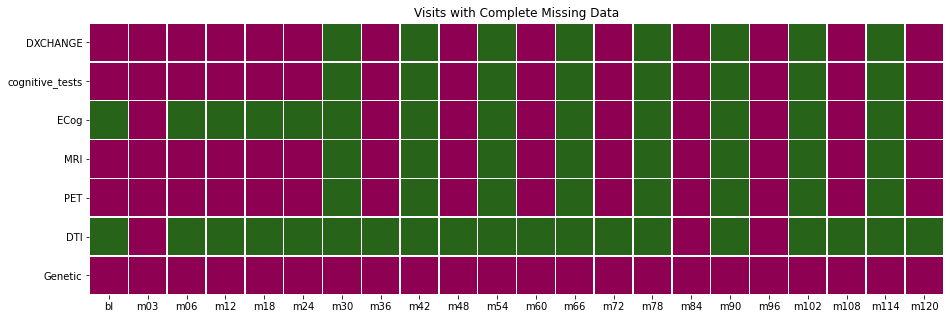

In [83]:
# dataframe to store visits with no measurement
no_data_df = pd.DataFrame(data=0, index=list(no_data_dict.keys()), columns=visit_type)

# populate dataframe with 1 where no measures at a visit
for k,v in no_data_dict.items():
    for visit in v:
        no_data_df.loc[k, visit] = 1
        
# plot
plt.figure(figsize = (16,5))
plt.title('Visits with Complete Missing Data')
sns.heatmap(no_data_df, cmap='PiYG', linewidths=.5, cbar=False, square=True)

In [84]:
# record shape of the full dataframe
original_df = df.shape

In [85]:
# drop rows with visit codes where there is no data
df.drop(df[df.VISCODE.isin(no_data_dict['MRI'])].index, inplace=True)

In [86]:
# record shape of new dataframe
new_df = df.shape
# display change
print(f'Removing the uninformative visit types dropped {original_df[0] - new_df[0]} rows.')

Removing the uninformative visit types dropped 1502 rows.


In [87]:
# display measures where we drop NaN rows from
print(remove_nan)

['ADAS13_bl', 'APOE4']


In [88]:
# list to store RID (patient identifier)
rid = []

# get RID for rows with missing genetic data
for p in df.loc[df.APOE4.isna(), 'RID']:
    rid.append(p)

# get RID for baseline rows with missing ADAS13 scores
for p in df.loc[(df.ADAS13_bl.isna()) & (df.VISCODE == 'bl'), 'RID']:
    rid.append(p)

# display results
print(f'There are a total of {len(rid)} patients to remove.')

There are a total of 8 patients to remove.


In [89]:
df.shape

(5438, 55)

In [90]:
# drop rows with identified RID values
df.drop(df[df.RID.isin(rid)].index, inplace=True)

In [91]:
df.shape

(5393, 55)

In [92]:
print(df.VISCODE[df.DXCHANGE.isna()].value_counts())
# display total
print(f'There are a total of {df.DXCHANGE.isna().sum()} missing diagnostic change values.')

m18     360
m96      22
m72      21
m108     21
m84      19
m60      14
m120     10
m24       2
Name: VISCODE, dtype: int64
There are a total of 469 missing diagnostic change values.


In [93]:
# dispaly diagnostic change codes
dx_change_ids

{1: 'Stable:NL to NL',
 2: 'Stable:MCI to MCI',
 3: 'Stable:AD to AD',
 4: 'Conv:NL to MCI',
 5: 'Conv:MCI to AD',
 6: 'Conv:NL to AD',
 7: 'Rev:MCI to NL',
 8: 'Rev:AD to MCI',
 9: 'Rev:AD to NL',
 -1: 'Not available'}

In [101]:
#df[df.RID == df.loc[(df.DXCHANGE.isna()) & (df.VISCODE == 'bl'), 'RID'].item()]

469

In [102]:
# remove m prefix from visit code
df.VISCODE = df.VISCODE.str.replace('m', '')
# replace bl code with 0
df.VISCODE = df.VISCODE.str.replace('bl', '0')
# change data type to int
df.VISCODE = df.VISCODE.astype('int')
# sort dataframe based on patient ID and visit codes
df.sort_values(by=['RID', 'VISCODE'], inplace=True)
# reset index now that the dataframe is sorted
df.reset_index(drop=True, inplace=True)

In [103]:
df.DXCHANGE = pd.to_numeric(df.DXCHANGE, errors='coerce')

In [104]:
df.DXCHANGE.isna().sum() - df.DXCHANGE[df.VISCODE == 3].isna().sum()

469

In [105]:
for i,r in df.iterrows():
    # fill in month 3 with baseline diagnosis
    if r.VISCODE == 3:
        df.iloc[i,5] = df.iloc[i-1,5]
    # check diagnostic change for NaN and whether the visit before and after has the same code
    # note that this checks to make sure the RID is consistant to ensure we're filling based on
    # a single patient
    elif pd.isna(df.iloc[i,5]) and df.iloc[i-1,5] == df.iloc[i+1,5] and df.iloc[i-1,0] == df.iloc[i+1,0]:
        # fill in value if consistent codes
        df.iloc[i,5] = df.iloc[i-1,5]

In [106]:
df.DXCHANGE.isna().sum()

132

In [107]:
df = df[df.DXCHANGE.isna() == False]

In [108]:
print(f'After cleaning up the dataset, there are a total of {df.shape[0]} cases between {len(df.RID.unique())} patients.')

After cleaning up the dataset, there are a total of 5261 cases between 811 patients.


In [109]:
# make headers lower case
df.columns = map(str.lower, df.columns)
# reset index
df.reset_index(drop=True, inplace=True)

In [110]:
for k,v in dx_change_ids.items():
    print(f'Value {k} represents {v}')

Value 1 represents Stable:NL to NL
Value 2 represents Stable:MCI to MCI
Value 3 represents Stable:AD to AD
Value 4 represents Conv:NL to MCI
Value 5 represents Conv:MCI to AD
Value 6 represents Conv:NL to AD
Value 7 represents Rev:MCI to NL
Value 8 represents Rev:AD to MCI
Value 9 represents Rev:AD to NL
Value -1 represents Not available


In [111]:
# list for patient IDs of converts
converts = []
for i,r in df.iterrows():
    if r.dxchange == 5 or r.dxchange == 6:
        converts.append(r.rid)
# display how many patients convert
print(len(converts))

245


In [112]:
# extract baseline info of patients that convert
dx_bl_df = df[(df.viscode == 0) & (df.rid.isin(converts))]

In [113]:
dx_bl_df.shape

(228, 55)

In [114]:
print(f'There are a total of {len(set(converts))} unique patient IDs.')

There are a total of 228 unique patient IDs.


In [115]:
# list to contain non-duplicate patient IDs
converts_u = []
# set to contain patient IDs with more than one occurance
converts_multi = set()
# loop through patient IDs
for patient in converts:
    # add patient ID if not a duplicate
    if patient not in converts_u and patient not in converts_multi:
        converts_u.append(patient)
    # add duplicates
    else:
        converts_multi.add(patient)
        try:
            converts_u.remove(patient)
        except:
            pass

In [116]:
print(f'There are a total of {len(converts_u)} patients that convert only once and {len(converts_multi)} patients with multiple conversions.')

There are a total of 213 patients that convert only once and 15 patients with multiple conversions.


In [117]:
dx_multi = df[df.rid.isin(converts_multi)]

In [118]:
dx_multi.dxchange.value_counts()

2.0    60
5.0    32
1.0    22
3.0    22
4.0     2
8.0     1
Name: dxchange, dtype: int64

In [119]:
dx_multi.head(20)

,rid,viscode,d1,d2,dx_bl,dxchange,age,ptgender,pteducat,ptethcat,...,av45_entorhinal_r,av1451_hippocampus_l,av1451_hippocampus_r,av1451_entorhinal_l,av1451_entorhinal_r,fa_hippocampus_l,fa_hippocampus_r,md_hippocampus_l,md_hippocampus_r,apoe4
36,101,0,1,1,LMCI,2.0,73.6,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
37,101,6,1,1,LMCI,2.0,73.6,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
38,101,12,1,1,LMCI,2.0,73.6,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
39,101,18,1,1,LMCI,2.0,73.6,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
40,101,24,1,1,LMCI,5.0,73.6,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
41,101,36,1,1,LMCI,5.0,73.6,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
42,101,48,1,1,LMCI,3.0,73.6,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
43,101,72,1,1,LMCI,3.0,73.6,Male,18,Not Hisp/Latino,...,1.1069,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
44,101,84,1,1,LMCI,3.0,73.6,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
45,1010,0,1,0,LMCI,2.0,74.2,Male,20,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [120]:
# list to store index values of visits that have repeated conversion diagnostic changes
dx_multi_index = []
for i,r in dx_multi.iterrows():
    # skip first row
    if i == 281:
        pass
    # check to see if current and previous diagnostic change are 5
    elif dx_multi.loc[i, 'dxchange'] == 5 and dx_multi.loc[i-1, 'dxchange'] == 5:
        # check to see if same patient
        if dx_multi.loc[i, 'rid'] == dx_multi.loc[i-1, 'rid']:
            # record index of visit
            dx_multi_index.append(i)

In [121]:
# recode dxchange 5 to 3 for repeated entries
for i in dx_multi_index:
    df.iloc[i, 5] = 3

In [122]:
# list for patient IDs of converts
converts = []
for i,r in df.iterrows():
    if r.dxchange == 5 or r.dxchange == 6:
        converts.append(r.rid)
# display how many patients convert
print(len(converts))

233


In [123]:
len(set(converts))

228

In [124]:
# list to contain non-duplicate patient IDs
converts_u = []
# set to contain patient IDs with more than one occurance
converts_multi = set()
# loop through patient IDs
for patient in converts:
    # add patient ID if not a duplicate
    if patient not in converts_u and patient not in converts_multi:
        converts_u.append(patient)
    # add duplicates
    else:
        converts_multi.add(patient)
        try:
            converts_u.remove(patient)
        except:
            pass

In [125]:
df[df.rid.isin(converts_multi)]

,rid,viscode,d1,d2,dx_bl,dxchange,age,ptgender,pteducat,ptethcat,...,av45_entorhinal_r,av1451_hippocampus_l,av1451_hippocampus_r,av1451_entorhinal_l,av1451_entorhinal_r,fa_hippocampus_l,fa_hippocampus_r,md_hippocampus_l,md_hippocampus_r,apoe4
411,1097,0,1,0,LMCI,2.0,73,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
412,1097,6,1,0,LMCI,2.0,73,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
413,1097,12,1,0,LMCI,2.0,73,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
414,1097,18,1,0,LMCI,2.0,73,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
415,1097,24,1,0,LMCI,2.0,73,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
416,1097,36,1,0,LMCI,2.0,73,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
417,1097,48,1,0,LMCI,5.0,73,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
418,1097,60,1,0,LMCI,3.0,73,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
419,1097,72,1,0,LMCI,5.0,73,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1534,1394,0,1,0,LMCI,2.0,77.1,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [126]:
# change set to list
converts_multi = list(converts_multi)
# display first patient
df[df.rid == converts_multi[0]]

,rid,viscode,d1,d2,dx_bl,dxchange,age,ptgender,pteducat,ptethcat,...,av45_entorhinal_r,av1451_hippocampus_l,av1451_hippocampus_r,av1451_entorhinal_l,av1451_entorhinal_r,fa_hippocampus_l,fa_hippocampus_r,md_hippocampus_l,md_hippocampus_r,apoe4
3481,566,0,1,1,LMCI,2.0,78.8,Male,20,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3482,566,6,1,1,LMCI,2.0,78.8,Male,20,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3483,566,12,1,1,LMCI,2.0,78.8,Male,20,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3484,566,18,1,1,LMCI,2.0,78.8,Male,20,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3485,566,24,1,1,LMCI,2.0,78.8,Male,20,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3486,566,36,1,1,LMCI,5.0,78.8,Male,20,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3487,566,60,1,1,LMCI,2.0,78.8,Male,20,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3488,566,72,1,1,LMCI,5.0,78.8,Male,20,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3489,566,84,1,1,LMCI,3.0,78.8,Male,20,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3490,566,96,1,1,LMCI,3.0,78.8,Male,20,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [127]:
# AD stable
df.loc[3486, 'dxchange'] = 5

In [128]:
# display next patient
df[df.rid == converts_multi[1]]

,rid,viscode,d1,d2,dx_bl,dxchange,age,ptgender,pteducat,ptethcat,...,av45_entorhinal_r,av1451_hippocampus_l,av1451_hippocampus_r,av1451_entorhinal_l,av1451_entorhinal_r,fa_hippocampus_l,fa_hippocampus_r,md_hippocampus_l,md_hippocampus_r,apoe4
411,1097,0,1,0,LMCI,2.0,73,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
412,1097,6,1,0,LMCI,2.0,73,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
413,1097,12,1,0,LMCI,2.0,73,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
414,1097,18,1,0,LMCI,2.0,73,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
415,1097,24,1,0,LMCI,2.0,73,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
416,1097,36,1,0,LMCI,2.0,73,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
417,1097,48,1,0,LMCI,5.0,73,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
418,1097,60,1,0,LMCI,3.0,73,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
419,1097,72,1,0,LMCI,5.0,73,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [129]:
# AD stable
df.loc[419, 'dxchange'] = 3

In [130]:
# display next patient
df[df.rid == converts_multi[2]]

,rid,viscode,d1,d2,dx_bl,dxchange,age,ptgender,pteducat,ptethcat,...,av45_entorhinal_r,av1451_hippocampus_l,av1451_hippocampus_r,av1451_entorhinal_l,av1451_entorhinal_r,fa_hippocampus_l,fa_hippocampus_r,md_hippocampus_l,md_hippocampus_r,apoe4
1777,166,0,1,1,CN,1.0,72.5,Female,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1778,166,6,1,1,CN,1.0,72.5,Female,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1779,166,12,1,1,CN,1.0,72.5,Female,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1780,166,18,1,1,CN,1.0,72.5,Female,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1781,166,24,1,1,CN,1.0,72.5,Female,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1782,166,36,1,1,CN,1.0,72.5,Female,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1783,166,60,1,1,CN,5.0,72.5,Female,18,Not Hisp/Latino,...,1.3196,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1784,166,72,1,1,CN,2.0,72.5,Female,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1785,166,84,1,1,CN,5.0,72.5,Female,18,Not Hisp/Latino,...,1.1321,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1786,166,96,1,1,CN,3.0,72.5,Female,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [131]:
# AD stable
df.loc[1783, 'dxchange'] = 4

In [132]:
# display next patient
df[df.rid == converts_multi[3]]

,rid,viscode,d1,d2,dx_bl,dxchange,age,ptgender,pteducat,ptethcat,...,av45_entorhinal_r,av1451_hippocampus_l,av1451_hippocampus_r,av1451_entorhinal_l,av1451_entorhinal_r,fa_hippocampus_l,fa_hippocampus_r,md_hippocampus_l,md_hippocampus_r,apoe4
1534,1394,0,1,0,LMCI,2.0,77.1,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1535,1394,6,1,0,LMCI,2.0,77.1,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1536,1394,12,1,0,LMCI,5.0,77.1,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1537,1394,18,1,0,LMCI,3.0,77.1,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1538,1394,24,1,0,LMCI,5.0,77.1,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1539,1394,36,1,0,LMCI,3.0,77.1,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1540,1394,48,1,0,LMCI,3.0,77.1,Male,18,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [133]:
# AD stable
df.loc[1538, 'dxchange'] = 3

In [134]:
# display next patient
df[df.rid == converts_multi[4]]

,rid,viscode,d1,d2,dx_bl,dxchange,age,ptgender,pteducat,ptethcat,...,av45_entorhinal_r,av1451_hippocampus_l,av1451_hippocampus_r,av1451_entorhinal_l,av1451_entorhinal_r,fa_hippocampus_l,fa_hippocampus_r,md_hippocampus_l,md_hippocampus_r,apoe4
4041,702,0,1,0,LMCI,2.0,85,Male,16,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4042,702,6,1,0,LMCI,2.0,85,Male,16,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4043,702,12,1,0,LMCI,2.0,85,Male,16,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4044,702,18,1,0,LMCI,2.0,85,Male,16,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4045,702,24,1,0,LMCI,5.0,85,Male,16,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4046,702,36,1,0,LMCI,8.0,85,Male,16,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4047,702,48,1,0,LMCI,5.0,85,Male,16,Not Hisp/Latino,...,1.441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4048,702,60,1,0,LMCI,3.0,85,Male,16,Not Hisp/Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4049,702,72,1,0,LMCI,3.0,85,Male,16,Not Hisp/Latino,...,1.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [137]:
len(converts)

233

In [138]:
# baseline dataframe of patients that convert
dx_df = df[df.rid.isin(converts)]

In [139]:
# extract baseline rows
dx_bl_df = dx_df[dx_df.viscode == 0]

In [140]:
len(dx_bl_df)

228

In [141]:
dx_bl_df.rid.value_counts()[:5]

179     1
1295    1
230     1
835     1
906     1
Name: rid, dtype: int64

In [142]:
# list to store indexes for visits to remove
visits_to_remove = []
for i,r in df.iterrows():
    try:
        # check to see if duplicate visit code for each patient
        if df.loc[i, 'viscode'] == df.loc[i-1, 'viscode'] and df.loc[i, 'rid'] == df.loc[i-1, 'rid']:
            # record duplicate index
            visits_to_remove.append(i)
    except:
        pass

In [143]:
len(visits_to_remove)

0

In [144]:
# drop duplicate rows
df.drop(df.loc[visits_to_remove].index, inplace=True)

In [145]:
# baseline dataframe of patients that convert
dx_df = df[df.rid.isin(converts)]

In [146]:
# extract baseline rows
dx_bl_df = dx_df[dx_df.viscode == 0]

In [147]:
len(dx_bl_df)

228

In [148]:
# save cleaned dataframe as csv
df.to_csv('df_cleaned.csv')